# Data Q&A Agent - Azure AI Foundry (Classic)

This notebook creates an Azure AI Foundry **classic** agent with Code Interpreter so you can upload CSV/Excel files and ask natural-language questions about your data.

This notebook uses **Foundry classic** (threads / runs / messages). Files are attached to **messages** via `MessageAttachment`, so the agent is created **once** and never republished when new files are uploaded.

## Local Prerequisites

- Python 3.14.3
- Option 1 (Conda): `conda create -n sample_foundry_classic python=3.14.3 ipykernel -y`
- Option 2 (venv): install Python 3.14, then run `py -3.14 -m venv .venv`
- `.env` file populated (copy from `.env.template`)
- `pip install -r requirements_classic.txt`

For full from-scratch setup (including installing Python/Conda), see `README.md`.

> **Note:** Agents (classic) are deprecated and will be retired on March 31, 2027.
> See the [migration guide](https://learn.microsoft.com/azure/foundry/agents/how-to/migrate) for the new experience.

## 1. Install Dependencies
Run this cell once in your active environment (`sample_foundry_classic`)

OR

Run `pip install -r requirements_classic.txt` in terminal

In [ ]:
# %pip install -r requirements_classic.txt --quiet

## 2. Setup & Configuration

In [7]:
import os
from pathlib import Path
from dotenv import load_dotenv

# Load .env — override=False so runtime env vars take precedence
load_dotenv(override=False)

PROJECT_ENDPOINT = os.getenv("FOUNDRY_PROJECT_ENDPOINT")
MODEL_DEPLOYMENT = os.getenv("FOUNDRY_MODEL_DEPLOYMENT_NAME")

print(f"Project endpoint : {PROJECT_ENDPOINT}")
print(f"Model deployment : {MODEL_DEPLOYMENT}")

Project endpoint : https://sample-proj-resource.services.ai.azure.com/api/projects/sample_project
Model deployment : gpt-4.1


## 3. Create the Classic Agent with Code Interpreter

The agent is created **once** with Code Interpreter enabled.

In Foundry classic, files are attached per-message via `MessageAttachment` — the agent definition never changes when files are uploaded.

In [8]:
from azure.ai.agents import AgentsClient
from azure.ai.agents.models import (
    CodeInterpreterTool,
    MessageAttachment,
    FilePurpose,
)
from azure.identity import DefaultAzureCredential

AGENT_NAME = "data-qa-agent-corteva-classic"

# Create the Agents client (classic)
agents_client = AgentsClient(
    endpoint=PROJECT_ENDPOINT,
    credential=DefaultAzureCredential(),
)

code_interpreter = CodeInterpreterTool()

# Create the agent ONCE — files are attached per-message, not here.
agent = agents_client.create_agent(
    model=MODEL_DEPLOYMENT,
    name=AGENT_NAME,
    instructions=(
        "You are a data analyst assistant. The user will upload CSV or Excel files. "
        "Use the Code Interpreter tool to load the data with pandas, explore it, "
        "and answer the user's questions. When useful, create charts or summary tables. "
        "Always show your work by printing intermediate results."
    ),
    tools=code_interpreter.definitions,
    tool_resources=code_interpreter.resources,
)

print(f"\u2705 Created agent — Name: {agent.name}, ID: {agent.id}")

✅ Created agent — Name: data-qa-agent-corteva-classic, ID: asst_1sp2Fv1ta097wgGc5Ye7SIbw


## 4. Create a Thread

In Foundry classic, a **thread** stores messages and maintains conversation state. One thread per conversation session.

In [30]:
thread = agents_client.threads.create()
print(f"Created thread: {thread.id}")

Created thread: thread_aHm6cjYRVALeJZNZ5aSIYcD3


## 5. Helper — `ask()`

A single function that handles all scenarios:
- **Just a question** — `ask("What's the total revenue?")`
- **Question + attach a file** — `ask("Summarize this", file_path="data.csv")`
- **Question + download generated files** — `ask("Add a profit column and save as Excel", download=True)`
- **All three** — `ask("Clean this and export", file_path="raw.csv", download=True)`

Files are uploaded and attached to the **message** via `MessageAttachment` — the agent is never modified.

In [31]:
from pathlib import Path

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


def ask(question: str, file_path: str = None, download: bool = False) -> str:
    """Ask the classic agent a question via threads / runs / messages.

    Files are uploaded and attached to the message as a MessageAttachment
    with Code Interpreter tool definitions. The agent definition stays
    unchanged — no republishing required.

    Args:
        question:  Your natural-language question or instruction.
        file_path: Optional path to a .csv/.xlsx file to upload for this turn.
        download:  If True, download any files the agent generates to output/.
                   Charts (image_file blocks) are always downloaded.
    """
    attachments = []

    # --- optionally upload a file and attach to the message ---
    if file_path:
        uploaded = agents_client.files.upload_and_poll(
            file_path=file_path,
            purpose=FilePurpose.AGENTS,
        )
        print(f"\U0001f4ce Uploaded: {file_path} \u2192 file ID: {uploaded.id}")

        attachment = MessageAttachment(
            file_id=uploaded.id,
            tools=CodeInterpreterTool().definitions,
        )
        attachments.append(attachment)

    # --- create a message (with optional file attachment) ---
    message = agents_client.messages.create(
        thread_id=thread.id,
        role="user",
        content=question,
        attachments=attachments if attachments else None,
    )
    print(f"\U0001f4ac Message created: {message.id}")

    # --- run the agent on the thread ---
    run = agents_client.runs.create_and_process(
        thread_id=thread.id,
        agent_id=agent.id,
    )

    if run.status == "failed":
        raise RuntimeError(f"Run failed: {run.last_error}")

    # --- collect the assistant's response ---
    messages = agents_client.messages.list(thread_id=thread.id)

    response_text = ""
    for msg in messages:
        if msg.role == "assistant":
            for block in msg.content:
                if block.type == "text":
                    response_text = block.text.value

                    if download:
                        for ann in block.text.annotations or []:
                            if ann.type == "file_path":
                                file_id = ann.file_path.file_id
                                fname = Path(ann.text).name if ann.text else f"output_{file_id}"
                                file_chunks = agents_client.files.get_content(file_id=file_id)
                                out_path = OUTPUT_DIR / fname
                                out_path.write_bytes(b"".join(file_chunks))
                                print(f"\u2b07\ufe0f  Downloaded: {out_path}")

                elif block.type == "image_file":
                    # Charts produced by Code Interpreter — always download.
                    file_id = block.image_file.file_id
                    out_path = OUTPUT_DIR / f"{file_id}.png"
                    file_chunks = agents_client.files.get_content(file_id=file_id)
                    out_path.write_bytes(b"".join(file_chunks))
                    print(f"\U0001f5bc\ufe0f  Downloaded chart: {out_path}")

            break  # only take the most recent assistant message

    return response_text


## 6. Try It — All Combinations in One Thread

The cells below show every combination of `ask()`:
1. Attach a file + ask a question
2. Follow-up question (no file, no download — agent remembers the CSV in the thread)
3. Ask for a generated file (download=True)
4. Another generated file request (download=True)

In [32]:
# 1\u20e3 Attach a file + ask a question
print("=" * 60)
print("1. Attach file + question")
print("=" * 60)

answer = ask(
    "What columns are in this file? Give me a quick summary.",
    file_path="sample_data/sample_sales.csv"
)

print(answer)

1. Attach file + question
📎 Uploaded: sample_data/sample_sales.csv → file ID: assistant-JqYqU5ZX6Wa5Y486LwRzd9
💬 Message created: msg_qWOZR9i1GIIJrrjfWmFHHSHm
Here is a quick summary of your file:

**Columns:**
1. date         — The date of the transaction/record
2. region       — The region where the transaction occurred
3. product      — The product sold
4. units_sold   — Number of units sold (integer)
5. unit_price   — Price per unit (float)
6. revenue      — Total revenue for that row (float)
7. cost         — Total cost for that row (float)

**Records:**  
There are 20 entries (rows) in the file.

**Sample data:**

| date       | region | product  | units_sold | unit_price | revenue | cost  |
|------------|--------|----------|------------|------------|---------|-------|
| 2025-01-05 | North  | Widget A | 120        | 25.0       | 3000.0  | 1800.0|
| 2025-01-12 | South  | Widget B |  85        | 40.0       | 3400.0  | 2125.0|
| 2025-01-19 | East   | Widget A |  95        | 25.0    

In [33]:
# 2\u20e3 Follow-up \u2014 no file, no download (agent remembers the CSV)
print("=" * 60)
print("2. Follow-up question (no file)")
print("=" * 60)
answer = ask("make a bar graph showing revenue by region")
print(answer)

2. Follow-up question (no file)
💬 Message created: msg_py4qXz4tDJ1XXV8zrekf88EE
🖼️  Downloaded chart: output\assistant-WDgvBeaRpBhYJHKuMxNVe5.png
Here is a bar graph showing total revenue by region. 

**Summary table:**

| Region | Total Revenue |
|--------|--------------|
| East   | 16,400.0     |
| North  | 20,400.0     |
| South  | 16,625.0     |
| West   | 13,800.0     |

The North region generated the highest total revenue, followed by South, East, and then West. If you'd like to see this by product or another variable, let me know!


assistant-WDgvBeaRpBhYJHKuMxNVe5.png


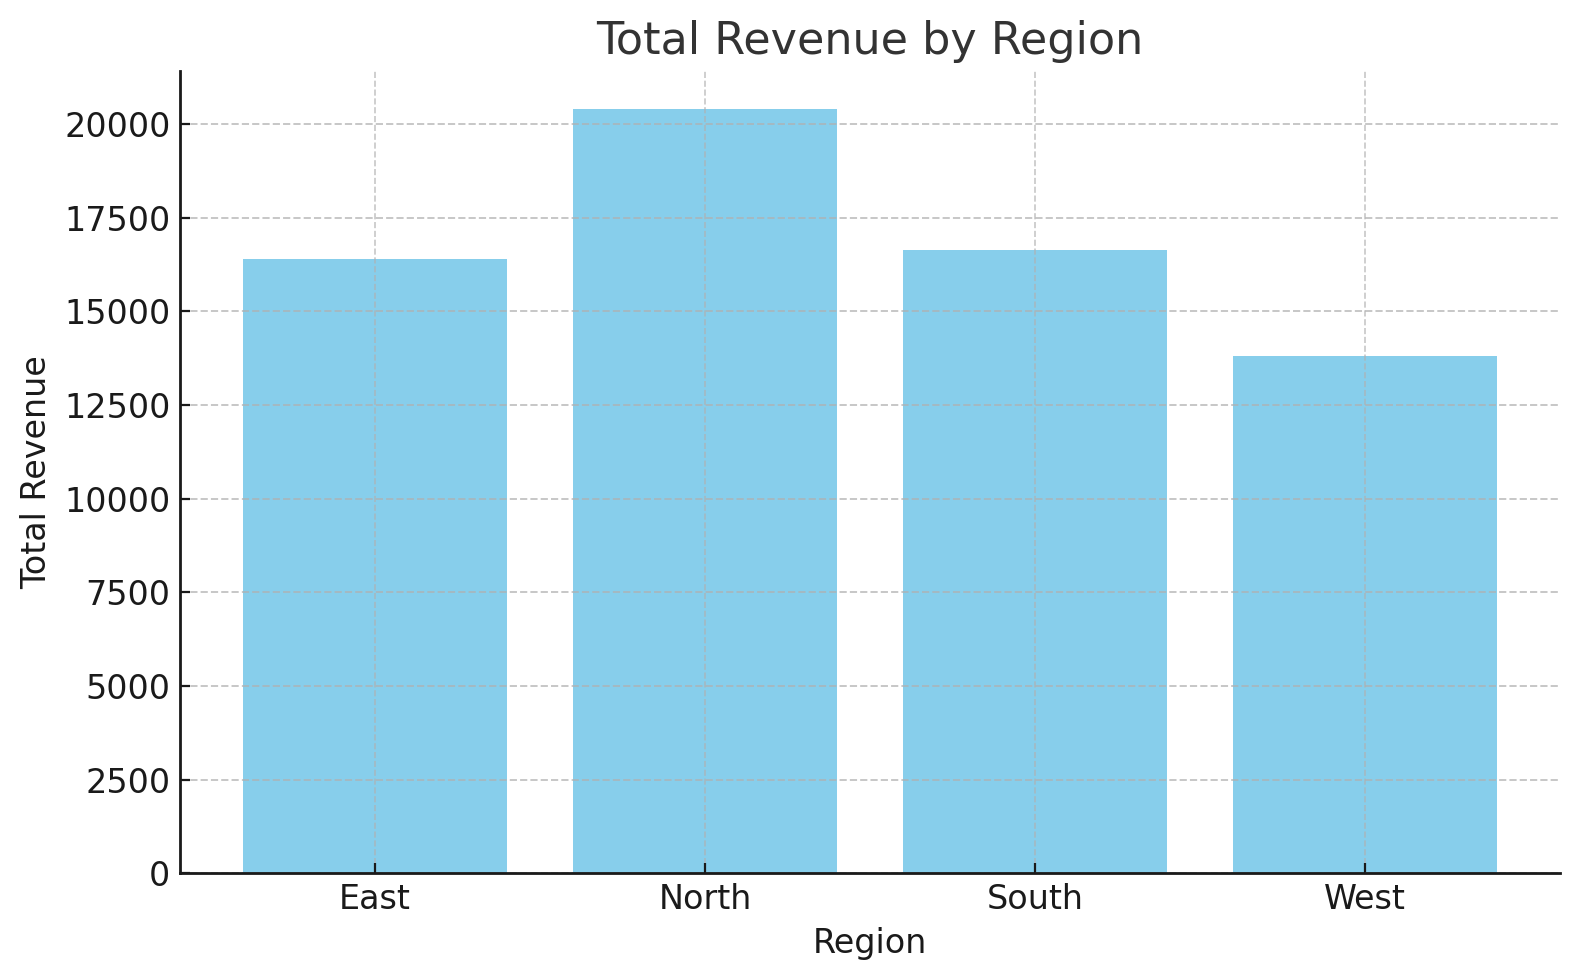

In [34]:
from pathlib import Path
from IPython.display import Image, display

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".gif", ".webp"}
imgs = [p for p in Path("output").iterdir() if p.suffix.lower() in IMAGE_EXTS]
imgs.sort(key=lambda p: p.stat().st_mtime)
for p in imgs[-3:]:   # last 3 generated
    print(p.name)
    display(Image(filename=str(p)))


In [ ]:
import shutil
from pathlib import Path
import os

shutil.rmtree(Path("output"), ignore_errors=True)
print("output/ deleted")


output/ deleted


FileNotFoundError: [WinError 2] The system cannot find the file specified: 'output'

In [6]:
# 2\u20e3 Follow-up \u2014 no file, no download (agent remembers the CSV)
print("=" * 60)
print("2. Follow-up question (no file)")
print("=" * 60)
answer = ask("Which region has the highest total revenue?")
print(answer)

2. Follow-up question (no file)
💬 Message created: msg_FjHgTmIlPJgoKlvp9LCHMlRq
The region with the highest total revenue is North, with a total of 20,400.0 in revenue. Here are the total revenues by region:

- North: 20,400.0
- South: 16,625.0
- East: 16,400.0
- West: 13,800.0

Let me know if you want a breakdown by product or another aspect!


In [10]:
# 3️⃣ Ask to generate a modified file → downloads to output/
print("=" * 60)
print("3. Generate + download a modified file")
print("=" * 60)
answer = ask(
    "Add a 'profit' column (revenue minus cost) and a 'profit_margin_pct' column. "
    "Save the result as a new Excel file.",
    download=True
)
print(answer)

3. Generate + download a modified file
💬 Message created: msg_zgtsEizgKQu4OTuiZYJM4Qoc
⬇️  Downloaded: output\enhanced_sales_data.xlsx
I've already completed those steps in my previous response!

You can download your enhanced file here:
[enhanced_sales_data.xlsx](sandbox:/mnt/data/enhanced_sales_data.xlsx)

This file includes:
- A **profit** column (revenue minus cost)
- A **profit_margin_pct** column (profit as a percentage of revenue)

Let me know if you need any additional analysis or modifications!


In [11]:
# 4\u20e3 Ask to generate another modified file \u2192 downloads to output/
print("=" * 60)
print("4. Generate + download another modified file")
print("=" * 60)
answer = ask(
    "add another column that indicates whether profit_margin_pct is >= 35 (1) or < (0)."
    "Save the result as a new Excel file.",
    download=True
)
print(answer)

4. Generate + download another modified file
💬 Message created: msg_LR5wKnXLJ5EObm2aubLBHve3
⬇️  Downloaded: output\enhanced_sales_data_with_margin_flag.xlsx
A new column, profit_margin_high, has been added, where:
- 1 indicates profit_margin_pct is 35% or higher,
- 0 indicates it's below 35%.

You can download the updated file here:
[enhanced_sales_data_with_margin_flag.xlsx](sandbox:/mnt/data/enhanced_sales_data_with_margin_flag.xlsx)


## 7. Cleanup

Delete the agent and thread when you're done.

In [ ]:
agents_client.threads.delete(thread_id=thread.id)
print(f"Thread '{thread.id}' deleted.")

agents_client.delete_agent(agent_id=agent.id)
print(f"Agent '{agent.id}' deleted.")